In [496]:
import random
from itertools import combinations
import matplotlib.pyplot as plt

random.seed(42)

In [497]:
courses = [
    ("AI", "DosenA"), ("ML", "DosenB"), ("DB", "DosenC"),
    ("CN", "DosenD"), ("SE", "DosenE"), ("OS", "DosenF"),
    ("IR", "DosenA"), ("NLP", "DosenB"), ("CV", "DosenC"),
    ("IOT", "DosenD"), ("HCI", "DosenE"), ("CyberSec", "DosenF"),
    ("BigData", "DosenA"), ("DL", "DosenB"), ("NoSQL", "DosenC"),
    ("Cloud", "DosenD"), ("UX", "DosenE"), ("SecEng", "DosenF"),
    ("Agile", "DosenA"), ("RL", "DosenB"), ("ETL", "DosenC"),
    ("DevOps", "DosenD"), ("GameDev", "DosenE"), ("Blockchain", "DosenF"),
]

rooms = ["R1", "R2", "R3", "R4"]
timeslots = ["Senin-08", "Senin-10", "Senin-13",
             "Selasa-08", "Selasa-10", "Selasa-13",
             "Rabu-08", "Rabu-10", "Rabu-13",
             "Kamis-08", "Kamis-10", "Kamis-13"]

N_COURSES = len(courses)        # 24
N_ROOMS = len(rooms)            # 4
N_SLOTS = len(timeslots)        # 12

def hari_dari_slot(slot):
    return slot.split("-")[0]

In [498]:
POP_SIZE = 60      # populasi awal
MAX_GEN = 100       # generasi maksimum
CX_RATE = 0.85       # tingkat crossover 85%
MUT_RATE = 0.20       # tingkat mutasi 20%

In [499]:
def buat_individu():
    return [(random.randrange(N_ROOMS), random.randrange(N_SLOTS)) for _ in range(N_COURSES)]

def buat_populasi():
    return [buat_individu() for _ in range(POP_SIZE)]

In [500]:
def hitung_konflik(individu):
    konflik = 0

    # Konflik Ruang: 2 MK pakai ruang sama di slot sama
    for (i, j) in combinations(range(N_COURSES), 2):
        r1, t1 = individu[i]
        r2, t2 = individu[j]
        if r1 == r2 and t1 == t2:
            konflik += 1

    # Konflik Dosen-Waktu: dosen sama mengajar >1 MK pada slot yang sama
    for (i, j) in combinations(range(N_COURSES), 2):
        dosen_i = courses[i][1]
        dosen_j = courses[j][1]
        if dosen_i == dosen_j:
            _, t1 = individu[i]
            _, t2 = individu[j]
            if t1 == t2:
                konflik += 1

    # Konflik Dosen-Hari: dosen sama mengajar >1 kali di hari yang sama (walau jam beda)
    for (i, j) in combinations(range(N_COURSES), 2):
        dosen_i = courses[i][1]
        dosen_j = courses[j][1]
        if dosen_i == dosen_j:
            _, t1 = individu[i]
            _, t2 = individu[j]
            if t1 != t2 and hari_dari_slot(timeslots[t1]) == hari_dari_slot(timeslots[t2]):
                konflik += 1

    return konflik

def hitung_fitness(individu):
    konflik = hitung_konflik(individu)
    fitness = 100 / (1 + konflik)
    return fitness, konflik

In [501]:
def seleksi_tournament(populasi, fitnesses, k=3):
    peserta = random.sample(range(len(populasi)), k)
    terbaik = max(peserta, key=lambda idx: fitnesses[idx])
    return populasi[terbaik]

In [502]:
def crossover(parent1, parent2):
    if random.random() < CX_RATE:
        titik = random.randint(1, N_COURSES - 1)
        anak1 = parent1[:titik] + parent2[titik:]
        anak2 = parent2[:titik] + parent1[titik:]
    else:
        anak1, anak2 = parent1[:], parent2[:]
    return anak1, anak2

In [503]:
def mutasi(individu):
    individu = individu[:]

    if random.random() < MUT_RATE:
        i = random.randint(0, N_COURSES - 1)
        individu[i] = (
            random.randrange(N_ROOMS),
            random.randrange(N_SLOTS)
        )

    return individu

In [504]:
def jalankan_ga():
    populasi = buat_populasi()
    riwayat_max = []
    riwayat_avg = []
    individu_terbaik_global = None
    fitness_terbaik_global = -1
    konflik_terbaik_global = None

    for gen in range(1, MAX_GEN + 1):
        hasil = [hitung_fitness(ind) for ind in populasi]
        fitnesses = [f for f, k in hasil]
        konfliks = [k for f, k in hasil]

        max_fit = max(fitnesses)
        avg_fit = sum(fitnesses) / len(fitnesses)
        riwayat_max.append(max_fit)
        riwayat_avg.append(avg_fit)

        idx_terbaik_gen = fitnesses.index(max_fit)
        if max_fit > fitness_terbaik_global:
            fitness_terbaik_global = max_fit
            individu_terbaik_global = populasi[idx_terbaik_gen][:]
            konflik_terbaik_global = konfliks[idx_terbaik_gen]

        print(
            f"Generasi {gen:3d} | "
            f"Fitness Maksimum = {max_fit:.2f} | "
            f"Fitness Rata-rata = {avg_fit:.2f}"
        )

        # Elitism
        populasi_baru = [populasi[idx_terbaik_gen][:]]
        while len(populasi_baru) < POP_SIZE:
            p1 = seleksi_tournament(populasi, fitnesses)
            p2 = seleksi_tournament(populasi, fitnesses)
            anak1, anak2 = crossover(p1, p2)
            anak1 = mutasi(anak1)
            anak2 = mutasi(anak2)
            populasi_baru.append(anak1)
            if len(populasi_baru) < POP_SIZE:
                populasi_baru.append(anak2)

        populasi = populasi_baru

    return individu_terbaik_global, fitness_terbaik_global, konflik_terbaik_global, riwayat_max, riwayat_avg

In [505]:
best_ind, best_fit, best_konflik, hist_max, hist_avg = jalankan_ga()

print("\n=== JADWAL TERBAIK ===")

for i, (mk, dosen) in enumerate(courses):
    r_idx, t_idx = best_ind[i]
    print(
        f"MK: {mk:<10} | "
        f"Ruang: {rooms[r_idx]} | "
        f"Waktu: {timeslots[t_idx]:<10} | "
        f"Dosen: {dosen}"
    )

print("\n=== HASIL EVALUASI AKHIR ===")
print(f"Fitness Terbaik : {best_fit:.2f}")
print(f"Jumlah Konflik  : {best_konflik}")

Generasi   1 | Fitness Maksimum = 11.11 | Fitness Rata-rata = 6.60
Generasi   2 | Fitness Maksimum = 14.29 | Fitness Rata-rata = 7.56
Generasi   3 | Fitness Maksimum = 14.29 | Fitness Rata-rata = 8.89
Generasi   4 | Fitness Maksimum = 14.29 | Fitness Rata-rata = 9.39
Generasi   5 | Fitness Maksimum = 14.29 | Fitness Rata-rata = 10.16
Generasi   6 | Fitness Maksimum = 20.00 | Fitness Rata-rata = 11.53
Generasi   7 | Fitness Maksimum = 25.00 | Fitness Rata-rata = 13.19
Generasi   8 | Fitness Maksimum = 25.00 | Fitness Rata-rata = 15.03
Generasi   9 | Fitness Maksimum = 25.00 | Fitness Rata-rata = 17.23
Generasi  10 | Fitness Maksimum = 25.00 | Fitness Rata-rata = 20.82
Generasi  11 | Fitness Maksimum = 33.33 | Fitness Rata-rata = 23.03
Generasi  12 | Fitness Maksimum = 33.33 | Fitness Rata-rata = 24.92
Generasi  13 | Fitness Maksimum = 33.33 | Fitness Rata-rata = 25.44
Generasi  14 | Fitness Maksimum = 50.00 | Fitness Rata-rata = 27.94
Generasi  15 | Fitness Maksimum = 50.00 | Fitness Ra

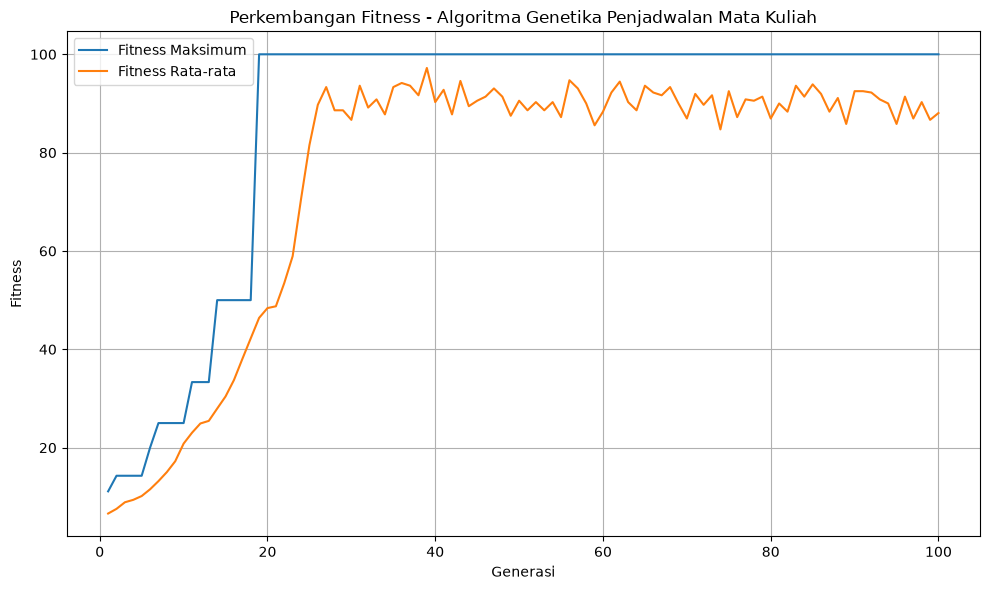

In [506]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, MAX_GEN + 1), hist_max, label="Fitness Maksimum")
plt.plot(range(1, MAX_GEN + 1), hist_avg, label="Fitness Rata-rata")
plt.title("Perkembangan Fitness - Algoritma Genetika Penjadwalan Mata Kuliah")
plt.xlabel("Generasi")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()